In [36]:
!pip3 install -q seaborn colorama tld plotly whois wordcloud gensim nltk tldextract hmmlearn pyquery pillow==9.5


In [37]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from urllib.parse import urlparse
from tld import get_tld, is_tld
from tld.exceptions import TldDomainNotFound, TldBadUrl, TldIOError
import whois
from plotly.subplots import make_subplots
from wordcloud import WordCloud
import tldextract
import hashlib
import math


In [38]:
urls_data = pd.read_csv("E:\DataSet\MaliciousURLsDataset.csv")
urls_data.head()

,url,type
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,malicious
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious
3,mail.printakid.com/www.online.americanexpress....,malicious
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious


In [39]:
urls_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551731 entries, 0 to 551730
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     551731 non-null  object
 1   type    551731 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [40]:
urls_data.isnull().sum()

url     0
type    0
dtype: int64

In [110]:
count = urls_data['type'].value_counts()

# Define a color scale for the bars
colors = [
    '#FF9466', '#FFC899', '#FF99FF', '#FFFFCC', '#66C2FF',
    '#E6C266', '#66A3E6', '#C2C2A3', '#A3FFA3', '#CC6666'
]
fig = go.Figure(data=[go.Bar(x=count.index, y=count, marker=dict(color=colors))])

# Update layout
fig.update_layout(
    xaxis_title='Types',
    yaxis_title='Count',
    title='Count of Different Types of URLs',
    plot_bgcolor='rgba(255,255,255,255)',  # Set plot background color to transparent
    paper_bgcolor='rgba(255,255,255,255)',  # Set paper background color to transparent
    font=dict(color='black')  # Set font color to white
)

# Update x-axis tick font color
fig.update_xaxes(tickfont=dict(color='black'))

# Update y-axis tick font color
fig.update_yaxes(tickfont=dict(color='black'))

fig.update_layout(width=400, height=400)
fig.show()

In [42]:
urls_data['url'] = urls_data['url'].replace('www.', '', regex=True)
urls_data['url'] = urls_data['url'].replace(r'^https?://', '', regex=True)
urls_data.head()

,url,type
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious
3,mail.printakid.com/online.americanexpress.com/...,malicious
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious


In [43]:
urls_data["type"].value_counts()

benign       395309
malicious    156422
Name: type, dtype: int64

In [44]:
urls_data["url_type"] = urls_data["type"].replace({
    'benign':0,
    'malicious':1,
});

In [45]:
urls_data.head()

,url,type,url_type
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1
3,mail.printakid.com/online.americanexpress.com/...,malicious,1
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1


In [46]:
def get_url_length(url):
    return len(url)

In [47]:
urls_data['url_len'] = urls_data['url'].apply(lambda x: get_url_length(str(x)))
urls_data['hostname_length'] = urls_data['url'].apply(lambda i: len(urlparse(i).netloc))
urls_data['path_length'] = urls_data['url'].apply(lambda i: len(urlparse(i).path))

In [48]:
#First Directory Length
def fd_length(url):
    urlpath= urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0

In [49]:
urls_data['fd_length'] = urls_data['url'].apply(lambda i: fd_length(i))

In [50]:
def count_http_https(url):
    return url.lower().count('http') + url.lower().count('https')


In [51]:
urls_data['http_count'] = urls_data['url'].apply(count_http_https)

In [52]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0


In [53]:
def extract_pri_domain(url):
    try:
        res = get_tld(url, as_object = True, fail_silently=False,fix_protocol=True)
        pri_domain= res.parsed_url.netloc
    except :
        pri_domain= None
    return pri_domain

In [54]:
urls_data['pri_domain'] = urls_data['url'].apply(lambda x: extract_pri_domain(x))

In [55]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com


In [56]:
def count_letters(url):
    num_letters = sum(char.isalpha() for char in url)
    return num_letters

def count_digits(url):
    num_digits = sum(char.isdigit() for char in url)
    return num_digits
def count_special_chars(url):
    special_chars = "!@#$%^&*()_+-=[]{};:,.<>/?`~|"
    num_special_chars = sum(char in special_chars for char in url)
    return num_special_chars

In [57]:
urls_data['letters_count'] =urls_data['url'].apply(lambda x: count_letters(x))
urls_data['digits_count']  =urls_data['url'].apply(lambda x: count_digits(x))
urls_data['special_chars_count']  =urls_data['url'].apply(lambda x: count_special_chars(x))

urls_data['count-'] = urls_data['url'].apply(lambda i: i.count('-'))
urls_data['count@'] = urls_data['url'].apply(lambda i: i.count('@'))
urls_data['count?'] = urls_data['url'].apply(lambda i: i.count('?'))
urls_data['count%'] = urls_data['url'].apply(lambda i: i.count('%'))
urls_data['count.'] = urls_data['url'].apply(lambda i: i.count('.'))
urls_data['count='] = urls_data['url'].apply(lambda i: i.count('='))

In [58]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,58,32,4,0,1,0,6,4
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,1,14,2,0,0,0,4,2
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,47,19,1,0,0,0,7,0
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,0,7,0,0,0,0,5,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,21,13,1,0,1,0,1,0


In [59]:
def has_shortening_service(url):
    pattern = re.compile(r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                         r'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                         r'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                         r'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                         r'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                         r'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                         r'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                         r'tr\.im|link\.zip\.net')
    match = pattern.search(url)
    return int(bool(match))

In [60]:
urls_data['shortened']  =urls_data['url'].apply(lambda x: has_shortening_service(x))

In [61]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=,shortened
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,58,32,4,0,1,0,6,4,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,1,14,2,0,0,0,4,2,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,47,19,1,0,0,0,7,0,0
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,0,7,0,0,0,0,5,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,21,13,1,0,1,0,1,0,0


In [62]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=,shortened
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,58,32,4,0,1,0,6,4,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,1,14,2,0,0,0,4,2,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,47,19,1,0,0,0,7,0,0
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,0,7,0,0,0,0,5,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,21,13,1,0,1,0,1,0,0


In [63]:
def have_ip_address(url):
    pattern = r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.' \
              r'([01]?\d\d?|2[0-4]\d|25[0-5])\/)|' \
              r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.' \
              r'([01]?\d\d?|2[0-4]\d|25[0-5])\/)|' \
              r'((0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2})\/)' \
              r'(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}|' \
              r'([0-9]+(?:\.[0-9]+){3}:[0-9]+)|' \
              r'((?:(?:\d|[01]?\d\d|2[0-4]\d|25[0-5])\.){3}(?:25[0-5]|2[0-4]\d|[01]?\d\d|\d)(?:\/\d{1,2})?)'

    match = re.search(pattern, url)
    if match:
        return 1
    else:
        return 0

In [64]:
urls_data['have_ip']  =urls_data['url'].apply(lambda x: have_ip_address(x))

In [65]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=,shortened,have_ip
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,58,32,4,0,1,0,6,4,0,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,1,14,2,0,0,0,4,2,0,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,47,19,1,0,0,0,7,0,0,0
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,0,7,0,0,0,0,5,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,21,13,1,0,1,0,1,0,0,0


In [66]:
urls_data.isnull().sum()

url                       0
type                      0
url_type                  0
url_len                   0
hostname_length           0
path_length               0
fd_length                 0
http_count                0
pri_domain             9009
letters_count             0
digits_count              0
special_chars_count       0
count-                    0
count@                    0
count?                    0
count%                    0
count.                    0
count=                    0
shortened                 0
have_ip                   0
dtype: int64

In [67]:
urls_data.fillna(0,inplace=True)

In [68]:
urls_data.isnull().sum()

url                    0
type                   0
url_type               0
url_len                0
hostname_length        0
path_length            0
fd_length              0
http_count             0
pri_domain             0
letters_count          0
digits_count           0
special_chars_count    0
count-                 0
count@                 0
count?                 0
count%                 0
count.                 0
count=                 0
shortened              0
have_ip                0
dtype: int64

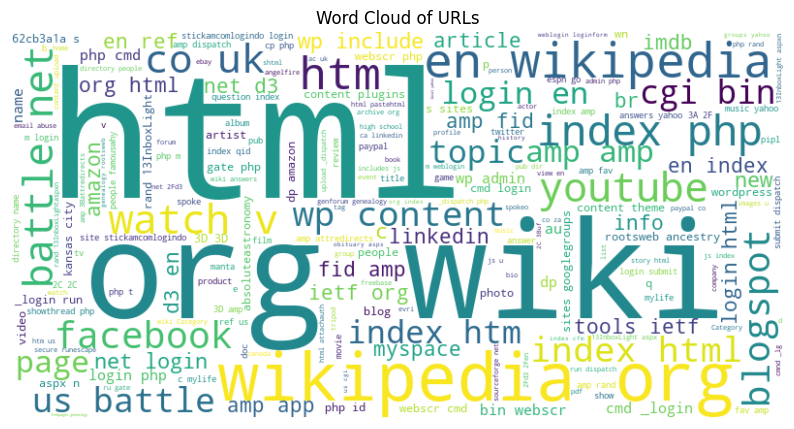

<Figure size 400x400 with 0 Axes>

In [69]:
# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(urls_data['url']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of URLs')
plt.figure(figsize=(4, 4))
plt.show()

In [70]:
# Histogram
fig = make_subplots(rows=1, cols=1)

fig.add_trace(go.Histogram(x=urls_data['url_len'], nbinsx=100))

fig.update_layout(
    title='Distribution of URL Lengths',
    xaxis_title='URL Length',
    yaxis_title='Count',
    template='plotly_dark',
    font=dict(color='white')
)
fig.update_layout(width=400, height=400)
fig.show()

In [71]:
# Bar chart for 'type' column
type_counts = urls_data['type'].value_counts()
fig = go.Figure(data=[go.Bar(x=type_counts.index, y=type_counts.values)])
fig.update_layout(title='Frequency of URL Types',
                  xaxis_title='URL Type',
                  yaxis_title='Count',
                  template='plotly_dark',
                  font=dict(color='white'),
                  showlegend=False)
fig.update_layout(width=400, height=400)
fig.show()

In [72]:
# Pie chart for 'url_type' column
url_type_counts = urls_data['url_type'].value_counts()
fig = go.Figure(data=[go.Pie(labels=url_type_counts.index, values=url_type_counts.values)])
fig.update_layout(title='Distribution of URL Types',
                  template='plotly_dark',
                  font=dict(color='white'),
                  showlegend=True)
fig.update_layout(width=400, height=400)
fig.show()

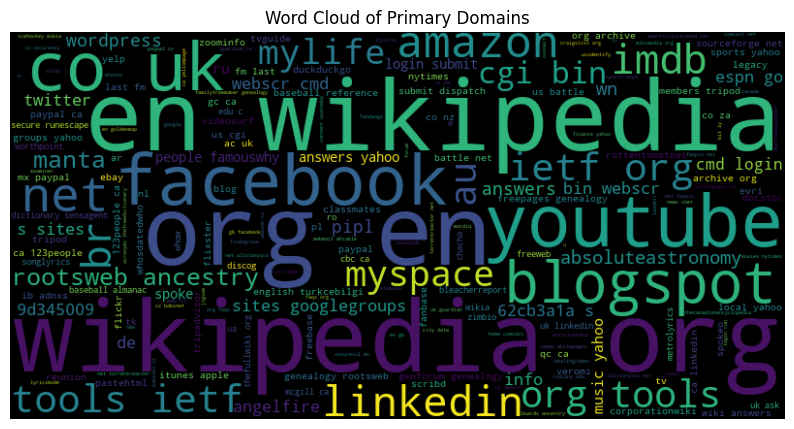

<Figure size 400x400 with 0 Axes>

In [73]:
# Convert pri_domain values to strings and filter out None and int values
filtered_domains = urls_data['pri_domain'].map(str).dropna()

# Concatenate all pri_domain values into a single string
text = ' '.join(filtered_domains)

# Generate the WordCloud data
wordcloud = WordCloud(background_color='black', colormap='viridis', width=800, height=400).generate(text)

# Plot the WordCloud using matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Primary Domains', color='black')
plt.figure(figsize=(4, 4))
plt.show()

In [74]:
# Create a DataFrame with the sum of each column
counts = urls_data[['letters_count', 'digits_count', 'special_chars_count']].sum()

# Create a bar chart for the counts of letters, digits, and special characters
fig = go.Figure(data=[
    go.Bar(name='Letters', x=['Count'], y=[counts['letters_count']]),
    go.Bar(name='Digits', x=['Count'], y=[counts['digits_count']]),
    go.Bar(name='Special Characters', x=['Count'], y=[counts['special_chars_count']])
])

fig.update_layout(title='Counts of Letters, Digits, and Special Characters',
                  xaxis_title='Type',
                  yaxis_title='Count',
                  barmode='group',
                  template='plotly_dark',
                  font=dict(color='white'))
fig.update_layout(width=400, height=400)
fig.show()

In [75]:
import plotly.graph_objects as go

# Define the special color for True count
true_color = 'green'

# Define the special color for False count
false_color = 'red'

# Plot bar chart for the 'shortened' column
shortened_counts = urls_data['shortened'].value_counts()
colors = [true_color if val else false_color for val in shortened_counts.index]
fig_shortened = go.Figure(data=go.Bar(x=shortened_counts.index, y=shortened_counts, marker_color=colors))
fig_shortened.update_layout(title='Counts of shortened',
                            xaxis_title='Value',
                            yaxis_title='Count',
                            template='plotly_dark',
                            font=dict(color='white'))
fig_shortened.update_layout(width=400, height=400)
fig_shortened.show()


# Plot bar chart for the 'have_ip' column
have_ip_counts = urls_data['have_ip'].value_counts()
colors = [true_color if val else false_color for val in have_ip_counts.index]
fig_have_ip = go.Figure(data=go.Bar(x=have_ip_counts.index, y=have_ip_counts, marker_color=colors))
fig_have_ip.update_layout(title='Counts of have_ip',
                          xaxis_title='Value',
                          yaxis_title='Count',
                          template='plotly_dark',
                          font=dict(color='white'))
fig_have_ip.update_layout(width=400, height=400)
fig_have_ip.show()

In [111]:
# Select only the numeric columns from the DataFrame
numeric_data = urls_data.select_dtypes(include='number')

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Create the heatmap trace
heatmap = go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='Greys',  # Use a grayscale color scale
)

# Create the layout
layout = go.Layout(
    title='Correlation Heatmap (Numeric Values Only)',
    xaxis=dict(title='Variables'),
    yaxis=dict(title='Variables'),
    plot_bgcolor='white',  # Set the background color to black
    paper_bgcolor='white',  # Set the plot area background color to black
    font=dict(color='black')  # Set the font color to white
)

# Create the Figure object
fig = go.Figure(data=heatmap, layout=layout)
# Display the heatmap
fig.show()


In [77]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=,shortened,have_ip
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,58,32,4,0,1,0,6,4,0,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,1,14,2,0,0,0,4,2,0,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,47,19,1,0,0,0,7,0,0,0
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,0,7,0,0,0,0,5,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,21,13,1,0,1,0,1,0,0,0


In [78]:
def get_url_region(primary_domain):
    ccTLD_to_region = {
    ".ac": "Ascension Island",
    ".ad": "Andorra",
    ".ae": "United Arab Emirates",
    ".af": "Afghanistan",
    ".ag": "Antigua and Barbuda",
    ".ai": "Anguilla",
    ".al": "Albania",
    ".am": "Armenia",
    ".an": "Netherlands Antilles",
    ".ao": "Angola",
    ".aq": "Antarctica",
    ".ar": "Argentina",
    ".as": "American Samoa",
    ".at": "Austria",
    ".au": "Australia",
    ".aw": "Aruba",
    ".ax": "Åland Islands",
    ".az": "Azerbaijan",
    ".ba": "Bosnia and Herzegovina",
    ".bb": "Barbados",
    ".bd": "Bangladesh",
    ".be": "Belgium",
    ".bf": "Burkina Faso",
    ".bg": "Bulgaria",
    ".bh": "Bahrain",
    ".bi": "Burundi",
    ".bj": "Benin",
    ".bm": "Bermuda",
    ".bn": "Brunei Darussalam",
    ".bo": "Bolivia",
    ".br": "Brazil",
    ".bs": "Bahamas",
    ".bt": "Bhutan",
    ".bv": "Bouvet Island",
    ".bw": "Botswana",
    ".by": "Belarus",
    ".bz": "Belize",
    ".ca": "Canada",
    ".cc": "Cocos Islands",
    ".cd": "Democratic Republic of the Congo",
    ".cf": "Central African Republic",
    ".cg": "Republic of the Congo",
    ".ch": "Switzerland",
    ".ci": "Côte d'Ivoire",
    ".ck": "Cook Islands",
    ".cl": "Chile",
    ".cm": "Cameroon",
    ".cn": "China",
    ".co": "Colombia",
    ".cr": "Costa Rica",
    ".cu": "Cuba",
    ".cv": "Cape Verde",
    ".cw": "Curaçao",
    ".cx": "Christmas Island",
    ".cy": "Cyprus",
    ".cz": "Czech Republic",
    ".de": "Germany",
    ".dj": "Djibouti",
    ".dk": "Denmark",
    ".dm": "Dominica",
    ".do": "Dominican Republic",
    ".dz": "Algeria",
    ".ec": "Ecuador",
    ".ee": "Estonia",
    ".eg": "Egypt",
    ".er": "Eritrea",
    ".es": "Spain",
    ".et": "Ethiopia",
    ".eu": "European Union",
    ".fi": "Finland",
    ".fj": "Fiji",
    ".fk": "Falkland Islands",
    ".fm": "Federated States of Micronesia",
    ".fo": "Faroe Islands",
    ".fr": "France",
    ".ga": "Gabon",
    ".gb": "United Kingdom",
    ".gd": "Grenada",
    ".ge": "Georgia",
    ".gf": "French Guiana",
    ".gg": "Guernsey",
    ".gh": "Ghana",
    ".gi": "Gibraltar",
    ".gl": "Greenland",
    ".gm": "Gambia",
    ".gn": "Guinea",
    ".gp": "Guadeloupe",
    ".gq": "Equatorial Guinea",
    ".gr": "Greece",
    ".gs": "South Georgia and the South Sandwich Islands",
    ".gt": "Guatemala",
    ".gu": "Guam",
    ".gw": "Guinea-Bissau",
    ".gy": "Guyana",
    ".hk": "Hong Kong",
    ".hm": "Heard Island and McDonald Islands",
    ".hn": "Honduras",
    ".hr": "Croatia",
    ".ht": "Haiti",
    ".hu": "Hungary",
    ".id": "Indonesia",
    ".ie": "Ireland",
    ".il": "Israel",
    ".im": "Isle of Man",
    ".in": "India",
    ".io": "British Indian Ocean Territory",
    ".iq": "Iraq",
    ".ir": "Iran",
    ".is": "Iceland",
    ".it": "Italy",
    ".je": "Jersey",
    ".jm": "Jamaica",
    ".jo": "Jordan",
    ".jp": "Japan",
    ".ke": "Kenya",
    ".kg": "Kyrgyzstan",
    ".kh": "Cambodia",
    ".ki": "Kiribati",
    ".km": "Comoros",
    ".kn": "Saint Kitts and Nevis",
    ".kp": "Democratic People's Republic of Korea (North Korea)",
    ".kr": "Republic of Korea (South Korea)",
    ".kw": "Kuwait",
    ".ky": "Cayman Islands",
    ".kz": "Kazakhstan",
    ".la": "Laos",
    ".lb": "Lebanon",
    ".lc": "Saint Lucia",
    ".li": "Liechtenstein",
    ".lk": "Sri Lanka",
    ".lr": "Liberia",
    ".ls": "Lesotho",
    ".lt": "Lithuania",
    ".lu": "Luxembourg",
    ".lv": "Latvia",
    ".ly": "Libya",
    ".ma": "Morocco",
    ".mc": "Monaco",
    ".md": "Moldova",
    ".me": "Montenegro",
    ".mf": "Saint Martin (French part)",
    ".mg": "Madagascar",
    ".mh": "Marshall Islands",
    ".mk": "North Macedonia",
    ".ml": "Mali",
    ".mm": "Myanmar",
    ".mn": "Mongolia",
    ".mo": "Macao",
    ".mp": "Northern Mariana Islands",
    ".mq": "Martinique",
    ".mr": "Mauritania",
    ".ms": "Montserrat",
    ".mt": "Malta",
    ".mu": "Mauritius",
    ".mv": "Maldives",
    ".mw": "Malawi",
    ".mx": "Mexico",
    ".my": "Malaysia",
    ".mz": "Mozambique",
    ".na": "Namibia",
    ".nc": "New Caledonia",
    ".ne": "Niger",
    ".nf": "Norfolk Island",
    ".ng": "Nigeria",
    ".ni": "Nicaragua",
    ".nl": "Netherlands",
    ".no": "Norway",
    ".np": "Nepal",
    ".nr": "Nauru",
    ".nu": "Niue",
    ".nz": "New Zealand",
    ".om": "Oman",
    ".pa": "Panama",
    ".pe": "Peru",
    ".pf": "French Polynesia",
    ".pg": "Papua New Guinea",
    ".ph": "Philippines",
    ".pk": "Pakistan",
    ".pl": "Poland",
    ".pm": "Saint Pierre and Miquelon",
    ".pn": "Pitcairn",
    ".pr": "Puerto Rico",
    ".ps": "Palestinian Territory",
    ".pt": "Portugal",
    ".pw": "Palau",
    ".py": "Paraguay",
    ".qa": "Qatar",
    ".re": "Réunion",
    ".ro": "Romania",
    ".rs": "Serbia",
    ".ru": "Russia",
    ".rw": "Rwanda",
    ".sa": "Saudi Arabia",
    ".sb": "Solomon Islands",
    ".sc": "Seychelles",
    ".sd": "Sudan",
    ".se": "Sweden",
    ".sg": "Singapore",
    ".sh": "Saint Helena",
    ".si": "Slovenia",
    ".sj": "Svalbard and Jan Mayen",
    ".sk": "Slovakia",
    ".sl": "Sierra Leone",
    ".sm": "San Marino",
    ".sn": "Senegal",
    ".so": "Somalia",
    ".sr": "Suriname",
    ".ss": "South Sudan",
    ".st": "São Tomé and Príncipe",
    ".sv": "El Salvador",
    ".sx": "Sint Maarten (Dutch part)",
    ".sy": "Syria",
    ".sz": "Eswatini",
    ".tc": "Turks and Caicos Islands",
    ".td": "Chad",
    ".tf": "French Southern Territories",
    ".tg": "Togo",
    ".th": "Thailand",
    ".tj": "Tajikistan",
    ".tk": "Tokelau",
    ".tl": "Timor-Leste",
    ".tm": "Turkmenistan",
    ".tn": "Tunisia",
    ".to": "Tonga",
    ".tr": "Turkey",
    ".tt": "Trinidad and Tobago",
    ".tv": "Tuvalu",
    ".tw": "Taiwan",
    ".tz": "Tanzania",
    ".ua": "Ukraine",
    ".ug": "Uganda",
    ".uk": "United Kingdom",
    ".us": "United States",
    ".uy": "Uruguay",
    ".uz": "Uzbekistan",
    ".va": "Vatican City",
    ".vc": "Saint Vincent and the Grenadines",
    ".ve": "Venezuela",
    ".vg": "British Virgin Islands",
    ".vi": "U.S. Virgin Islands",
    ".vn": "Vietnam",
    ".vu": "Vanuatu",
    ".wf": "Wallis and Futuna",
    ".ws": "Samoa",
    ".ye": "Yemen",
    ".yt": "Mayotte",
    ".za": "South Africa",
    ".zm": "Zambia",
    ".zw": "Zimbabwe"
    }
    
    for ccTLD in ccTLD_to_region:
        if primary_domain.endswith(ccTLD):
            return ccTLD_to_region[ccTLD]
    
    return "Global"

In [79]:
urls_data['url_region'] = urls_data['pri_domain'].apply(lambda x: get_url_region(str(x)))

In [80]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,...,special_chars_count,count-,count@,count?,count%,count.,count=,shortened,have_ip,url_region
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,...,32,4,0,1,0,6,4,0,0,Italy
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,...,14,2,0,0,0,4,2,0,0,Global
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,...,19,1,0,0,0,7,0,0,0,Global
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,...,7,0,0,0,0,5,0,0,0,Global
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,...,13,1,0,1,0,1,0,0,0,Global


In [81]:
# Count the occurrences of each region
region_counts = urls_data['url_region'].value_counts()

# Add a count for 'Global' if it doesn't exist in the DataFrame
if 'Global' not in region_counts.index:
    region_counts['Global'] = 0

# Create a dataframe for the region counts
data = pd.DataFrame({'region': region_counts.index, 'count': region_counts.values})

# Define the colorscale for the choropleth
colorscale = 'YlOrRd'  # Change the colorscale to 'YlOrRd' for a more vibrant color scheme

# Create the Choropleth chart
fig = go.Figure(data=go.Choropleth(
    locations=data['region'],
    z=data['count'],
    locationmode='country names',
    colorscale=colorscale,
    autocolorscale=True,  # Set autocolorscale to True for vibrant colors
    marker_line_color='white',
    colorbar_title='Count'
))

# Set the chart title
fig.update_layout(title_text='Distribution of URL Regions')
fig.update_layout(width=400, height=400)
# Display the chart
fig.show()

In [82]:
def extract_root_domain(url):
    extracted = tldextract.extract(url)
    root_domain = extracted.domain
    return root_domain

In [83]:
urls_data['root_domain'] = urls_data['pri_domain'].apply(lambda x: extract_root_domain(str(x)))

In [84]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,...,count-,count@,count?,count%,count.,count=,shortened,have_ip,url_region,root_domain
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,...,4,0,1,0,6,4,0,0,Italy,nobell
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,...,2,0,0,0,4,2,0,0,Global,dghjdgf
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,...,1,0,0,0,7,0,0,0,Global,serviciosbys
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,...,0,0,0,0,5,0,0,0,Global,printakid
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,...,1,0,1,0,1,0,0,0,Global,thewhiskeydregs


In [85]:
urls_data.isnull().sum()

url                    0
type                   0
url_type               0
url_len                0
hostname_length        0
path_length            0
fd_length              0
http_count             0
pri_domain             0
letters_count          0
digits_count           0
special_chars_count    0
count-                 0
count@                 0
count?                 0
count%                 0
count.                 0
count=                 0
shortened              0
have_ip                0
url_region             0
root_domain            0
dtype: int64

In [86]:
urls_data.shape

(551731, 22)

In [87]:
urls_data.duplicated().sum()

43014

In [88]:
urls_data.drop_duplicates(inplace=True)

In [89]:
urls_data.columns

Index(['url', 'type', 'url_type', 'url_len', 'hostname_length', 'path_length',
       'fd_length', 'http_count', 'pri_domain', 'letters_count',
       'digits_count', 'special_chars_count', 'count-', 'count@', 'count?',
       'count%', 'count.', 'count=', 'shortened', 'have_ip', 'url_region',
       'root_domain'],
      dtype='object')

In [90]:
urls_data.head()

,url,type,url_type,url_len,hostname_length,path_length,fd_length,http_count,pri_domain,letters_count,...,count-,count@,count?,count%,count.,count=,shortened,have_ip,url_region,root_domain
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,malicious,1,225,0,134,35,0,nobell.it,135,...,4,0,1,0,6,4,0,0,Italy,nobell
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,malicious,1,77,0,77,12,0,dghjdgf.com,62,...,2,0,0,0,4,2,0,0,Global,dghjdgf
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,malicious,1,177,0,177,76,0,serviciosbys.com,111,...,1,0,0,0,7,0,0,0,Global,serviciosbys
3,mail.printakid.com/online.americanexpress.com/...,malicious,1,56,0,56,26,0,mail.printakid.com,49,...,0,0,0,0,5,0,0,0,Global,printakid
4,thewhiskeydregs.com/wp-content/themes/widescre...,malicious,1,116,0,79,10,0,thewhiskeydregs.com,82,...,1,0,1,0,1,0,0,0,Global,thewhiskeydregs


In [91]:
urls_data.to_csv("E:\DataSet\MaliciousURLsProcessed.csv", index=False)

In [92]:
data = urls_data.drop(columns=['url','type','pri_domain'])
data.head()

,url_type,url_len,hostname_length,path_length,fd_length,http_count,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=,shortened,have_ip,url_region,root_domain
0,1,225,0,134,35,0,135,58,32,4,0,1,0,6,4,0,0,Italy,nobell
1,1,77,0,77,12,0,62,1,14,2,0,0,0,4,2,0,0,Global,dghjdgf
2,1,177,0,177,76,0,111,47,19,1,0,0,0,7,0,0,0,Global,serviciosbys
3,1,56,0,56,26,0,49,0,7,0,0,0,0,5,0,0,0,Global,printakid
4,1,116,0,79,10,0,82,21,13,1,0,1,0,1,0,0,0,Global,thewhiskeydregs


In [93]:
data['root_domain'].value_counts()

wikipedia                                  13425
youtube                                     8633
facebook                                    8338
blogspot                                    8089
yahoo                                       5846
                                           ...  
gawvanmale                                     1
gavoyager                                      1
gauthierhoughtalingandwilliamsreview           1
gauthierhoughtalingandwilliamslawonline        1
barclaycardus                                  1
Name: root_domain, Length: 147054, dtype: int64

In [94]:
data = data[data['root_domain'] != '0']

In [95]:
data['root_domain'].value_counts()

wikipedia                                  13425
youtube                                     8633
facebook                                    8338
blogspot                                    8089
yahoo                                       5846
                                           ...  
gawvanmale                                     1
gavoyager                                      1
gauthierhoughtalingandwilliamsreview           1
gauthierhoughtalingandwilliamslawonline        1
barclaycardus                                  1
Name: root_domain, Length: 147053, dtype: int64

In [96]:
len(data['root_domain'].value_counts())

147053

In [97]:
def hash_encode(category):
    hash_object = hashlib.md5(category.encode())
    return int(hash_object.hexdigest(), 16) % (10 ** 8)

In [98]:
# Apply hash encoding to the categorical feature
data['root_domain'] = data['root_domain'].apply(hash_encode)

In [99]:
# Apply hash encoding to the categorical feature
data['url_region'] = data['url_region'].apply(hash_encode)

In [100]:
data.head()

,url_type,url_len,hostname_length,path_length,fd_length,http_count,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=,shortened,have_ip,url_region,root_domain
0,1,225,0,134,35,0,135,58,32,4,0,1,0,6,4,0,0,10018174,110860
1,1,77,0,77,12,0,62,1,14,2,0,0,0,4,2,0,0,32604616,69762684
2,1,177,0,177,76,0,111,47,19,1,0,0,0,7,0,0,0,32604616,41195063
3,1,56,0,56,26,0,49,0,7,0,0,0,0,5,0,0,0,32604616,48938178
4,1,116,0,79,10,0,82,21,13,1,0,1,0,1,0,0,0,32604616,36338401


In [101]:
data.shape

(504438, 19)

In [102]:
data.isnull().sum()

url_type               0
url_len                0
hostname_length        0
path_length            0
fd_length              0
http_count             0
letters_count          0
digits_count           0
special_chars_count    0
count-                 0
count@                 0
count?                 0
count%                 0
count.                 0
count=                 0
shortened              0
have_ip                0
url_region             0
root_domain            0
dtype: int64

In [103]:
data.to_csv("E:\DataSet\MaliciousURLsTransformed.csv", index=False)

In [104]:
data.describe()

,url_type,url_len,hostname_length,path_length,fd_length,http_count,letters_count,digits_count,special_chars_count,count-,count@,count?,count%,count.,count=,shortened,have_ip,url_region,root_domain
count,504438.000000,504438.000000,504438.0,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,504438.000000,5.044380e+05,5.044380e+05
mean,0.216512,51.036334,0.0,43.856450,8.254212,0.009232,39.440790,4.655765,6.893333,1.198294,0.003792,0.163986,0.097057,1.943129,0.279095,0.068470,0.000680,3.617795e+07,5.040993e+07
std,0.411868,42.851131,0.0,27.329876,10.323065,0.127685,30.193278,11.271983,5.438768,2.499549,0.067491,0.469451,1.140470,1.453459,0.937063,0.252551,0.026067,1.439048e+07,2.787714e+07
min,0.000000,4.000000,0.0,1.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.667860e+05,2.209000e+03
25%,0.000000,29.000000,0.0,26.000000,4.000000,0.000000,24.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.260462e+07,2.717711e+07
50%,0.000000,41.000000,0.0,37.000000,6.000000,0.000000,33.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,3.260462e+07,5.075759e+07
75%,0.000000,60.000000,0.0,53.000000,10.000000,0.000000,47.000000,6.000000,8.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,3.260462e+07,7.347265e+07
max,1.000000,2307.000000,0.0,2175.000000,408.000000,10.000000,2141.000000,545.000000,209.000000,42.000000,10.000000,166.000000,134.000000,37.000000,34.000000,1.000000,1.000000,9.986509e+07,9.999982e+07
